<a href="https://colab.research.google.com/github/Ethan-Shak/SC3021_SDAB_Group_3/blob/main/SC3021_Group_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
#All relevant imports for the notebook
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import requests
import datetime
from datetime import datetime
import numpy as np
import scipy.stats as stats
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# **Which Risk Factors Drive Diabetes Worldwide?**
DADI VENKAT ROHIT, ETHAN SHAK JIN JIE, AND RADINKA SHANMUGANANTHAM

# **HYPOTHESIS**
According to the International Diabetes Federation, approximately 537 million adults aged 20-79 were living with diabetes in 2021, and this number is projected to rise to 783 million by 2045. Even in Singapore, we face a rising type 2 diabetes epidemic with 11.4% prevalence among adults and projections reaching 786,000 by 2050.

Early detection and risk assessment are crucial for prevention and management. This raises an important question on how multi-country health data can improve diabetes risk prediction for our ethnically-diverse population.

In this context, we will explore the possible correlation between different risk factors (metabolic, demographic, lifestyle, and medical) during diabetes prediction across multiple countries. We hypothesize that combining data from geographically and demographically diverse populations will improve model accuracy and help identify the most significant risk factors that drive diabetes internationally.






# **DATA SOURCE IDENTIFICATION AND EXPLORATION**

## **Requirement Analysis:** To tackle the problem, we need to have comprehensive health data about individuals that includes measurements of key diabetes risk factors.

This data needs to be aligned across multiple countries to enable transfer learning. For accurate analysis, it is desirable to have sufficient data on individuals across different demographic groups and geographic regions, requiring a broad coverage of countries. It is sufficient to have one summary entry per individual (no single events in records) because the prediction aims at overall diabetes status. Risk factors vary across populations so we do not need temporal data at fine granularity (day or month may be enough).

The necessary data we will use include well-established risk factors such as age, body mass index (BMI), blood glucose levels etc. This allows the model to capture how long-term health indicators and inherited risk contribute to diabetes development.

Environmental factors are excluded from this study, as the focus is placed on personal health metrics and clinical indicators that are directly measurable and actionable. Thus increasing the robustness of our data analysis.


**List of considered sources:**

We researched several sources to have as varied populations as possible from different countries.

India https://www.kaggle.com/datasets/ankushpanday1/diabetes-prediction-in-india-dataset

Bangladesh https://www.kaggle.com/datasets/abdelazizsami/early-stage-diabetes-risk-prediction

USA BRFSS
https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset

Indonesia
https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

Pima Indians https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

USA NHANES https://www.kaggle.com/datasets/cdc/national-health-and-nutrition-examination-survey

## **Dataset 1: India diabetes dataset**

This dataset contains 5,292 anonymised health records from individuals in India, with 27 demographic, lifestyle, and clinical attributes designed to support prediction of diabetes

In [39]:
df_india = pd.read_csv('/content/drive/MyDrive/SC3021/diabetes_prediction_india.csv')
print(df_india.head())

   Age  Gender   BMI Family_History Physical_Activity       Diet_Type  \
0   48    Male  35.5             No              High  Non-Vegetarian   
1   18   Other  28.7            Yes            Medium  Non-Vegetarian   
2   21   Other  30.0            Yes              High  Non-Vegetarian   
3   25  Female  25.6             No            Medium      Vegetarian   
4   78    Male  38.8             No              High  Non-Vegetarian   

  Smoking_Status Alcohol_Intake Stress_Level Hypertension  ...  \
0          Never            NaN       Medium          Yes  ...   
1        Current       Moderate         High           No  ...   
2        Current       Moderate         High          Yes  ...   
3         Former       Moderate         High          Yes  ...   
4        Current           High         High           No  ...   

   Health_Insurance  Regular_Checkups  Medication_For_Chronic_Conditions  \
0                No                No                                 No   
1           

**Comments on the data set for India**

This dataset looks at diabetes risk in the Indian population using a combination of personal, lifestyle, and health-related factors. It also includes information such as diet type, physical activity, smoking, stress level, and regular health checkups, which can help show how daily habits and existing health conditions may be linked to diabetes status.

However some variables may be based on self-reported information, which can affect accuracy.

## **Dataset 2: Bangladesh diabetes dataset**

This dataset contains sign and symptom data of newly diabetic or at‑risk patients, collected via questionnaire at Sylhet Diabetes Hospital in Bangladesh.

In [40]:
df_bangladesh = pd.read_csv('/content/drive/MyDrive/SC3021/bangladesh_diabetes.csv')
print(df_bangladesh.head())

   Age Gender Polyuria Polydipsia sudden weight loss weakness Polyphagia  \
0   40   Male       No        Yes                 No      Yes         No   
1   58   Male       No         No                 No      Yes         No   
2   41   Male      Yes         No                 No      Yes        Yes   
3   45   Male       No         No                Yes      Yes        Yes   
4   60   Male      Yes        Yes                Yes      Yes        Yes   

  Genital thrush visual blurring Itching Irritability delayed healing  \
0             No              No     Yes           No             Yes   
1             No             Yes      No           No              No   
2             No              No     Yes           No             Yes   
3            Yes              No     Yes           No             Yes   
4             No             Yes     Yes          Yes             Yes   

  partial paresis muscle stiffness Alopecia Obesity     class  
0              No              Yes      

**Comments on the data set for Bangladesh**

This dataset, collected from patients at Sylhet Diabetes Hospital in Sylhet, Bangladesh, focuses on the signs and symptoms of newly diagnosed diabetic patients or those at risk of developing diabetes. By emphasizing early warning signs rather than lab results, it enables identification of at-risk individuals before clinical diagnosis. The inclusion of less common symptoms like genital thrush and partial paresis may reveal interesting patterns, though self-reported data could introduce bias and lifestyle factors such as diet or exercise are not included. The dataset is intended for predicting the likelihood of diabetes at an early stage using data mining techniques.

## Dataset 3: USA BRFSS diabetes dataset

This dataset aggregates 253k+ BRFSS 2015 survey responses in the USA, including lifestyle, comorbidities, and health indicators, and includes a diabetes label derived from survey responses.

In [41]:
df_USA_BRFSS = pd.read_csv('/content/drive/MyDrive/SC3021/AMERICAA_diabetes.csv')
print(df_USA_BRFSS.head())

   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0   

**Comments on the data set for USA BRFSS**

This dataset comes from the 2015 Behavioral Risk Factor Surveillance System, which includes information on clinical factors, lifestyle behaviors, mental and physical health, and socioeconomic background, allowing for a wide-ranging analysis of diabetes risk.

The data also covers access to healthcare and preventive services, which makes it possible to explore health disparities. With three categories of diabetes no diabetes, prediabetes, and diabetes the dataset supports detailed modeling and helps identify early warning signs of the disease.


## Dataset 4: Indonesia diabetes dataset

This dataset contains 100,000 de‑identified patient records with demographic and clinical variables

In [42]:
df_Indonesia = pd.read_csv('/content/drive/MyDrive/SC3021/Indonesia_diabetes_prediction_dataset.csv')
print(df_Indonesia.head())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


**Comments on the data set for Indonesia**

This Indonesia diabetes dataset contains individual-level records and includes key risk factors such as age, BMI, HbA1c level, blood glucose level, as well as hypertension, heart disease, gender, and smoking history.


The target variable diabetes is binary (0/1), making it suitable for supervised classification to estimate diabetes risk.

## **Dataset 5: Pima Indians diabetes dataset**

This dataset contains medical measurements of female Pima Indian patients aged ≥21 years from the National Institute of Diabetes and Digestive and Kidney Diseases.

In [43]:
df_pima = pd.read_csv('/content/drive/MyDrive/SC3021/pima_indians_diabetes.csv')
print(df_pima.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


**Comments on the data set for Pima Indians**

This dataset focuses on a specific population, Pima Indian heritage with high diabetes prevalence, making it valuable for studying genetic predisposition. The diabetes pedigree function is a unique feature that quantifies family history using a specialized algorithm.

However, the dataset only includes females aged 21+, which limits generalizability. The glucose tolerance test results provide clinical-grade measurements that could be strong predictors.

## **Dataset 6: USA NHANES diabetes dataset**

This dataset contains official NHANES survey data from the CDC, combining interviews, physical exams, and laboratory tests on ~10,000 US participants per 2-year cycle to assess health/nutrition status across diverse ethnicities.


In [48]:
from functools import reduce

#Load the relevant CSV files
df_demo = pd.read_csv('/content/drive/MyDrive/SC3021/NHANES_demographic.csv')
df_exam = pd.read_csv('/content/drive/MyDrive/SC3021/NHANES_examination.csv')
df_labs = pd.read_csv('/content/drive/MyDrive/SC3021/NHANES_labs.csv')
df_quest = pd.read_csv('/content/drive/MyDrive/SC3021/NHANES_questionnaire.csv')

#Selected only the columns relevant to diabetes factors
demo_cols  = ['SEQN', 'RIDAGEYR', 'RIAGENDR']
exam_cols  = ['SEQN', 'BMXBMI', 'BPXSY1', 'BPXDI1']
labs_cols  = ['SEQN', 'LBXTC']
quest_cols = ['SEQN', 'DIQ010', 'MCQ160C', 'MCQ160E', 'SMQ040',
              'BPQ050A', 'BPQ080', 'PAQ605', 'PAQ650', 'PAQ620']

df_demo = df_demo[demo_cols]
df_exam = df_exam[exam_cols]
df_labs = df_labs[labs_cols]
df_quest = df_quest[quest_cols]
dataframes = [df_demo, df_exam, df_labs, df_quest]

# Inner Join of all dataframes on 'SEQN'
df_USA_NHANES = reduce(lambda left, right: pd.merge(left, right, on='SEQN', how='inner'), dataframes)

rename_dict = {
    'SEQN': 'patient_id',
    'RIDAGEYR': 'age_years',
    'RIAGENDR': 'gender_code',
    'BMXBMI': 'bmi',
    'BPXSY1': 'systolic_bp',
    'BPXDI1': 'diastolic_bp',
    'LBXTC': 'total_cholesterol',
    'DIQ010': 'diabetes_status',
    'MCQ160C': 'coronary_heart_disease',
    'MCQ160E': 'heart_attack',
    'SMQ040': 'current_smoker_status',
    'BPQ050A': 'taking_bp_meds',
    'BPQ080': 'taking_cholesterol_meds',
    'PAQ605': 'vigorous_work_activity',
    'PAQ650': 'vigorous_recreational_activity',
    'PAQ620': 'moderate_work_activity'
}

existing_renames = {k: v for k, v in rename_dict.items() if k in df_USA_NHANES.columns}
df_USA_NHANES.rename(columns=existing_renames, inplace=True)

print(df_USA_NHANES.head())

   patient_id  age_years  gender_code   bmi  systolic_bp  diastolic_bp  \
0       73557         69            1  26.7        122.0          72.0   
1       73558         54            1  28.6        156.0          62.0   
2       73559         72            1  28.9        140.0          90.0   
3       73560          9            1  17.1        108.0          38.0   
4       73561         73            2  19.7        136.0          86.0   

   total_cholesterol  diabetes_status  coronary_heart_disease  heart_attack  \
0              167.0              1.0                     2.0           2.0   
1              170.0              1.0                     2.0           2.0   
2              126.0              1.0                     2.0           2.0   
3              168.0              2.0                     NaN           NaN   
4              201.0              2.0                     2.0           2.0   

   current_smoker_status  taking_bp_meds  taking_cholesterol_meds  \
0          

**Comments on the data set for USA NHANES**

This dataset from the CDC's National Health and Nutrition Examination Survey is unique as it combines self-reported questionnaire responses with objective, gold-standard laboratory tests and physical examinations (such as clinician-measured blood pressure, HbA1c, and BMI).

By integrating clinical accuracy with broad lifestyle data across a nationally representative, multi-ethnic US sample, it significantly reduces the recall bias often found in pure survey datasets.

However, because it is aggregated across multiple distinct survey modules, it requires complex structuring to derive standardized binary health indicators for integration.

# **EXPLORATION OF DATA QUALITY**

## **India Dataset Profiling**

### **Dimensions and Attributes**  
  
We check how many rows (observations) and list out columns (attributes) which are in the dataset to get a sense of its scale and complexity.

In [57]:
num_rows = df_india.shape[0]
num_cols = df_india.shape[1]
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print("\nDataset Columns:")
for col in df_india.columns:
    print("-", col)

Number of rows: 5292
Number of columns: 27

Dataset Columns:
- Age
- Gender
- BMI
- Family_History
- Physical_Activity
- Diet_Type
- Smoking_Status
- Alcohol_Intake
- Stress_Level
- Hypertension
- Cholesterol_Level
- Fasting_Blood_Sugar
- Postprandial_Blood_Sugar
- HBA1C
- Heart_Rate
- Waist_Hip_Ratio
- Urban_Rural
- Health_Insurance
- Regular_Checkups
- Medication_For_Chronic_Conditions
- Pregnancies
- Polycystic_Ovary_Syndrome
- Glucose_Tolerance_Test_Result
- Vitamin_D_Level
- C_Protein_Level
- Thyroid_Condition
- Diabetes_Status


### **Missing/NULL values**

We check for missing data that might need imputation (mean, median, mode) or removal depending on severity and feature importance.

In [53]:
print(f"This dataset contains missing/NULL values: {df_USA_BRFSS.isnull().any().any()}")
missing_values = df_india.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])

This dataset contains missing/NULL values: False
Missing values per column:
 Alcohol_Intake    1780
dtype: int64


### **Data types**
Many columns have Yes/No or categorical entries.

We map and convert these into numeric or categorical types for easier analysis and modeling.

In [59]:
print("Data types before conversion:")
display(df_india.dtypes)
# Convert categorical yes/no columns to binary (0 = No, 1 = Yes)
yes_no_cols = ['Family_History', 'Hypertension', 'Health_Insurance',
               'Regular_Checkups', 'Medication_For_Chronic_Conditions',
               'Polycystic_Ovary_Syndrome', 'Thyroid_Condition', 'Diabetes_Status']
for col in yes_no_cols:
    df_india[col] = df_india[col].map({'No': 0, 'Yes': 1})
# Convert categorical columns to categorical dtype
cat_cols = ['Gender', 'Diet_Type', 'Physical_Activity', 'Smoking_Status', 'Alcohol_Intake', 'Stress_Level', 'Urban_Rural']
for col in cat_cols:
    df_india[col] = df_india[col].astype('category')
print("\nData types after conversion:")
display(df_india.dtypes)

Data types before conversion:


,0
Age,int64
Gender,object
BMI,float64
Family_History,object
Physical_Activity,object
Diet_Type,object
Smoking_Status,object
Alcohol_Intake,object
Stress_Level,object
Hypertension,object



Data types after conversion:


,0
Age,int64
Gender,category
BMI,float64
Family_History,int64
Physical_Activity,category
Diet_Type,category
Smoking_Status,category
Alcohol_Intake,category
Stress_Level,category
Hypertension,int64


### **Class Balance for Target variable**

We visualize the target variable (Diabetes_Status) using a bar and pie chart to examine class imbalance. In this case, resampling is not required.

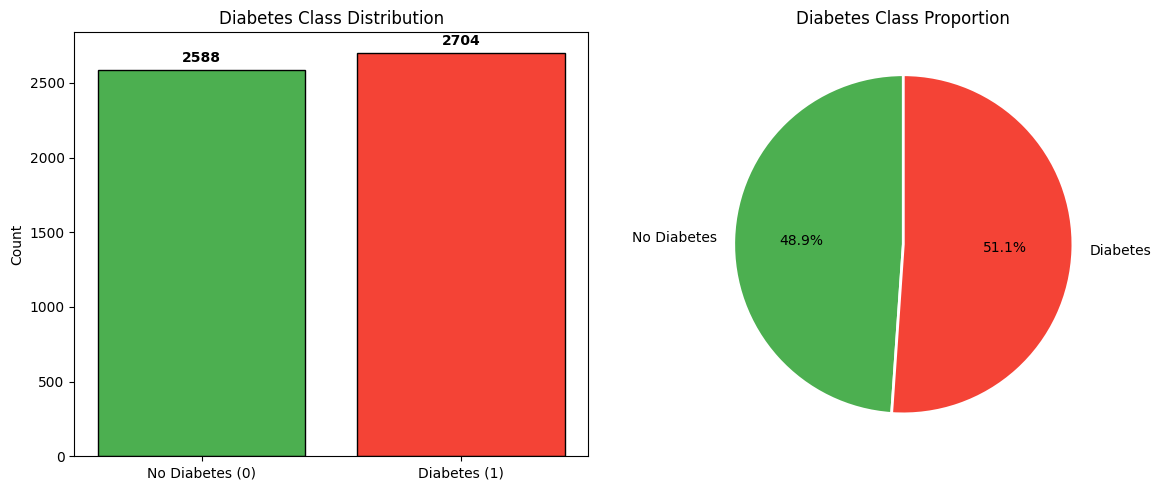

In [60]:
# Check distribution of target variable (Diabetes_Status)
vc = df_india['Diabetes_Status'].value_counts()
# Bar and pie plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Bar chart
bars = axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'],
                   [vc.get(0, 0), vc.get(1, 0)],
                   color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title('Diabetes Class Distribution')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, [vc.get(0, 0), vc.get(1, 0)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 50, val, ha='center', fontweight='bold')
# Pie chart
axes[1].pie([vc.get(0, 0), vc.get(1, 0)],
            labels=['No Diabetes', 'Diabetes'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=90)
axes[1].set_title('Diabetes Class Proportion')
plt.tight_layout()
plt.show()

### **Exploration of Variables**

We use histograms to see how numerical measures like BMI, glucose levels, or HbA1c are distributed.

We visualise the proportion of binary health indicators like hypertension or thyroid via bar charts.

We use these to identify any extreme values, skewness, and potential outliers

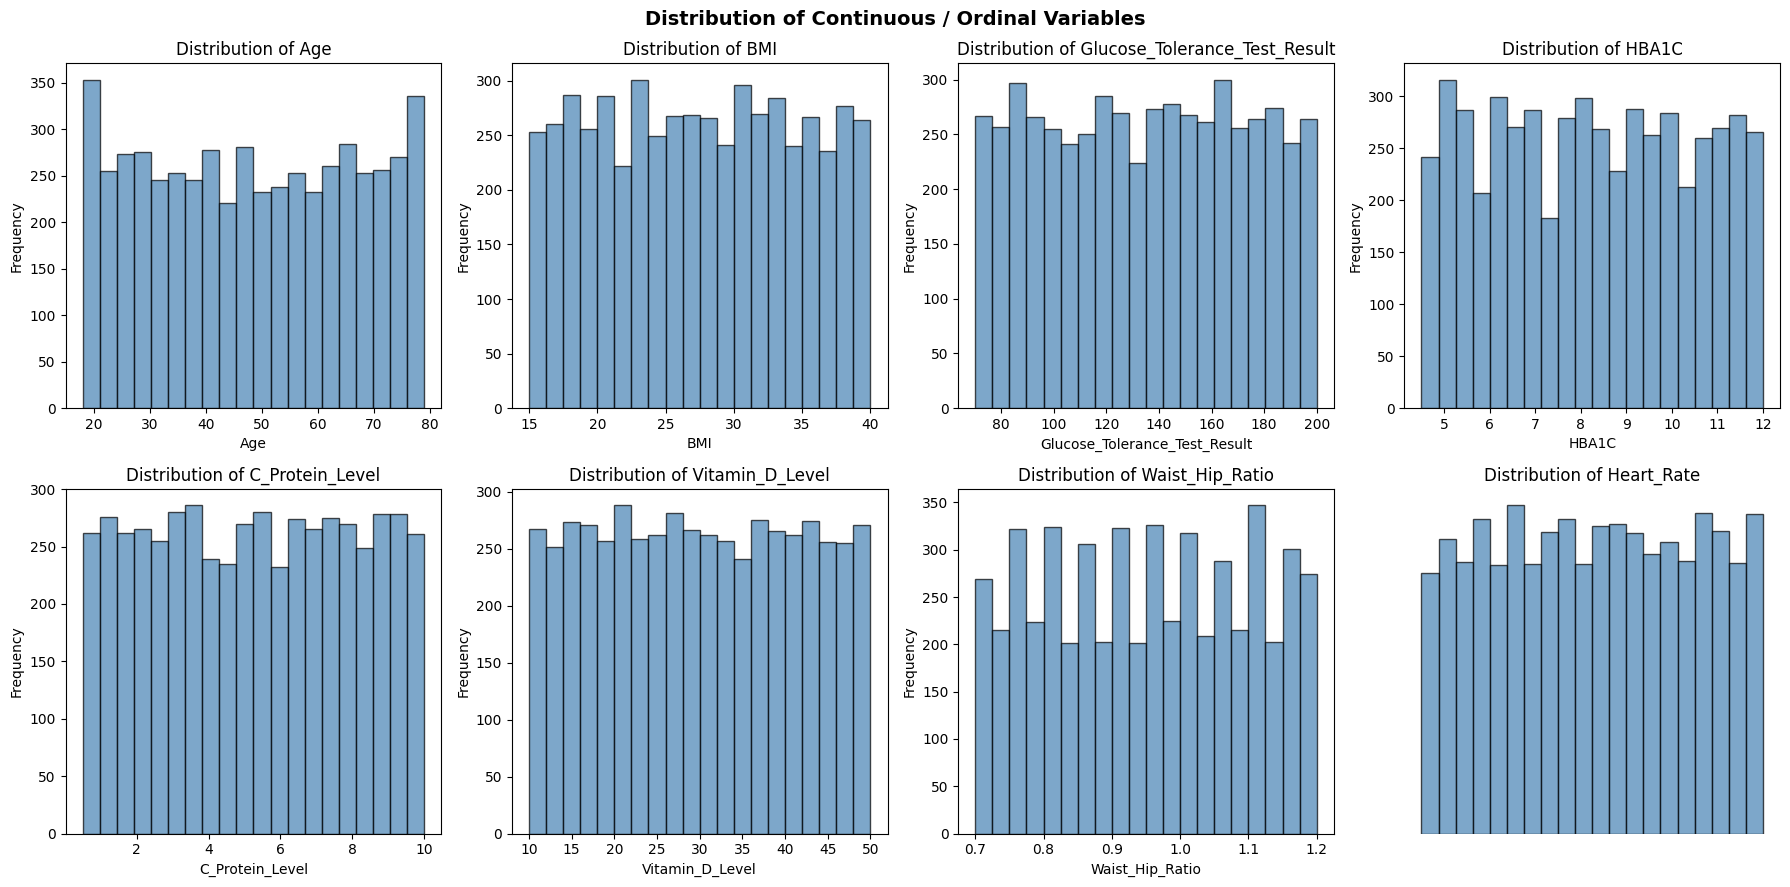

In [63]:
continuous_cols = ['Age', 'BMI', 'Glucose_Tolerance_Test_Result', 'HBA1C',
                   'C_Protein_Level', 'Vitamin_D_Level', 'Waist_Hip_Ratio', 'Heart_Rate']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    axes[i].hist(df_india[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
axes[-1].axis('off')
plt.suptitle('Distribution of Continuous / Ordinal Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

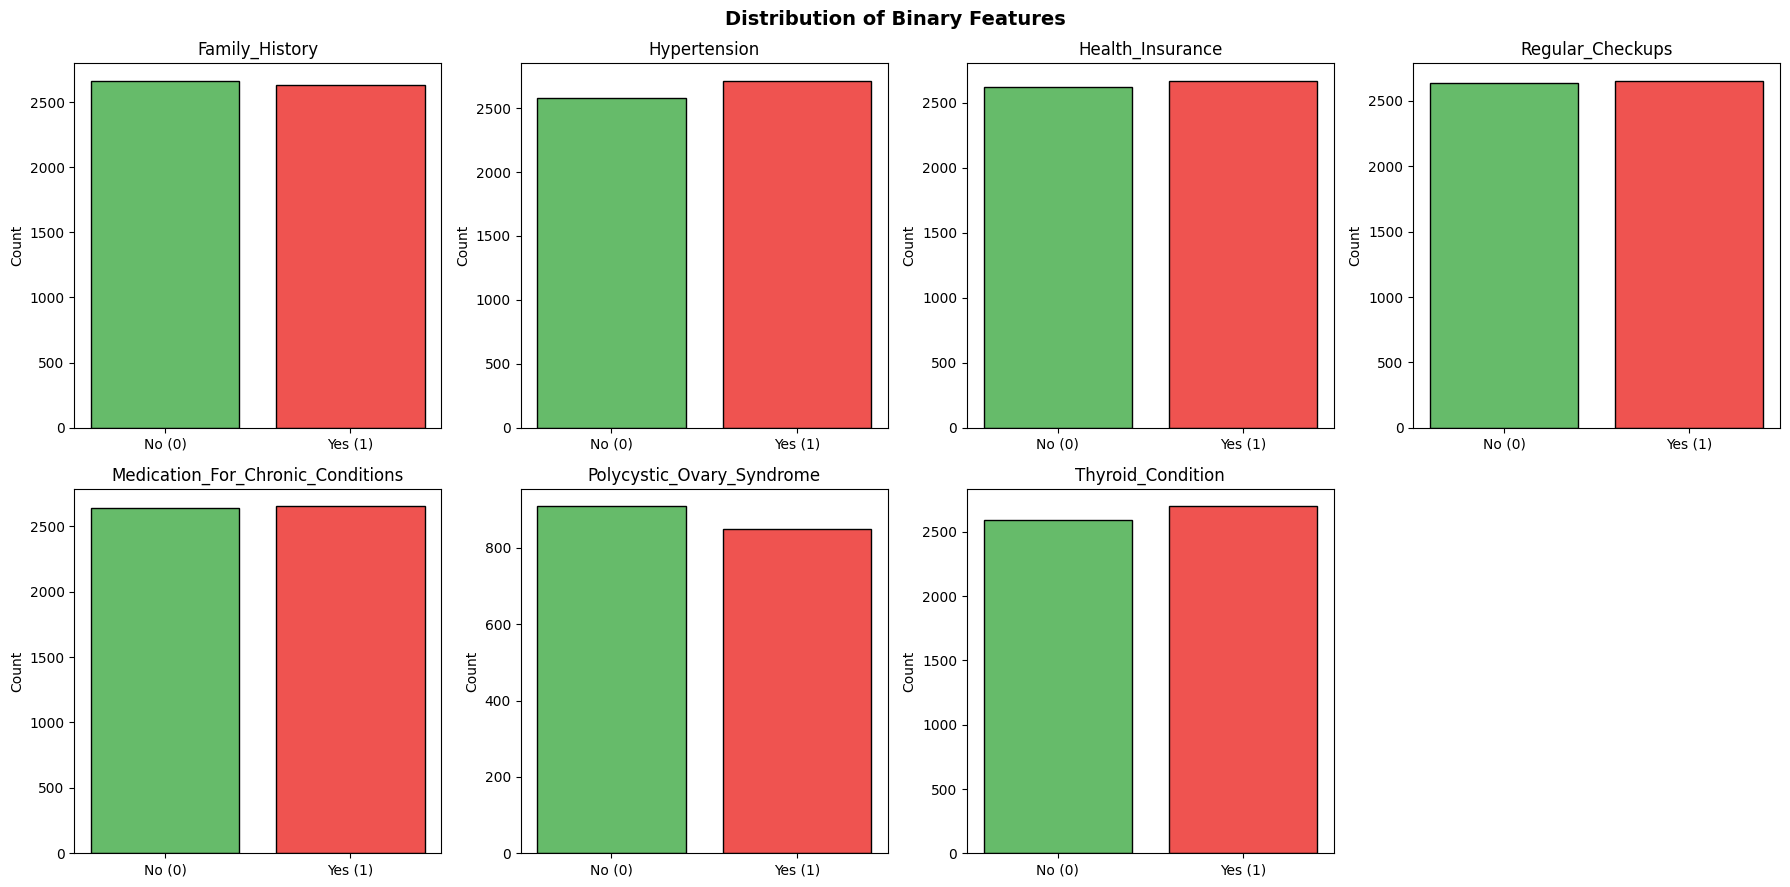

In [61]:
binary_cols = ['Family_History', 'Hypertension', 'Health_Insurance',
               'Regular_Checkups', 'Medication_For_Chronic_Conditions',
               'Polycystic_Ovary_Syndrome', 'Thyroid_Condition']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(binary_cols):
    counts = df_india[col].value_counts()
    axes[i].bar(['No (0)', 'Yes (1)'],
                [counts.get(0, 0), counts.get(1, 0)],
                color=['#66BB6A', '#EF5350'], edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
for j in range(len(binary_cols), len(axes)):
    axes[j].axis('off')
plt.suptitle('Distribution of Binary Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **USA BRFSS Dataset Profiling**

### **Dimensions and Attributes**  
  
We check how many rows (observations) and list out columns (attributes) which are in the dataset to get a sense of its scale and complexity.

In [64]:
num_rows = df_USA_BRFSS.shape[0]
num_cols = df_USA_BRFSS.shape[1]
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print(f"\nDataset Columns:")
for i in df_USA_BRFSS.columns:
  print("- "+ i)

Number of rows: 253680
Number of columns: 22

Dataset Columns:
- Diabetes_binary
- HighBP
- HighChol
- CholCheck
- BMI
- Smoker
- Stroke
- HeartDiseaseorAttack
- PhysActivity
- Fruits
- Veggies
- HvyAlcoholConsump
- AnyHealthcare
- NoDocbcCost
- GenHlth
- MentHlth
- PhysHlth
- DiffWalk
- Sex
- Age
- Education
- Income


In [55]:
print(f"This dataset contains missing/NULL values: {df_USA_BRFSS.isnull().any().any()}")
print(f"No missing values were detected so no imputation is required")

This dataset contains missing/NULL values: False
No missing values were detected so no imputation is required


### **Data types**
All columns are currently float64, but most are binary (0/1) or categorical integers.

We convert them to integer types since decimal points are not meaningful for these columns.

In [71]:
print("Data types before conversion:")
display(df_USA_BRFSS.dtypes)

# Convert all columns to int instead of float
for col in df_USA_BRFSS.columns:
    df_USA_BRFSS[col] = df_USA_BRFSS[col].astype(int)

print("\nData types after conversion:")
display(df_USA_BRFSS.dtypes)


Data types before conversion:


,0
Diabetes_binary,int64
HighBP,int64
HighChol,int64
CholCheck,int64
BMI,int64
Smoker,int64
Stroke,int64
HeartDiseaseorAttack,int64
PhysActivity,int64
Fruits,int64



Data types after conversion:


,0
Diabetes_binary,int64
HighBP,int64
HighChol,int64
CholCheck,int64
BMI,int64
Smoker,int64
Stroke,int64
HeartDiseaseorAttack,int64
PhysActivity,int64
Fruits,int64


### **Class Balance for Target variable**

We visualize the target variable (Diabetes_Status) using a bar and pie chart to examine class imbalance. In this case, the dataset is imbalanced, with 86.1% non-diabetic and 13.9% diabetic cases.

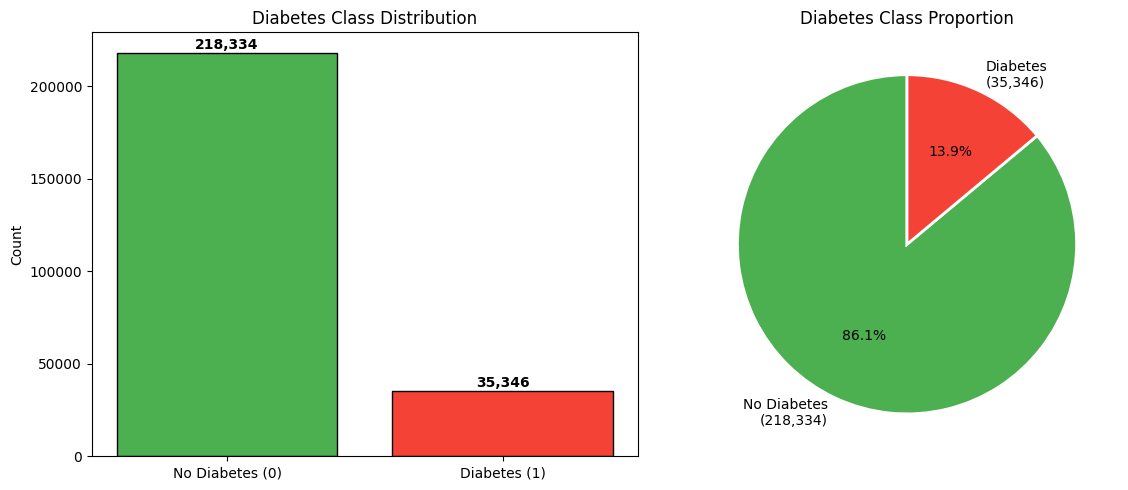

In [72]:
vc = df_USA_BRFSS['Diabetes_binary'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'], [vc[0], vc[1]],
                    color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_ylabel('Count')
axes[0].set_title('Diabetes Class Distribution')
for bar, val in zip(bars, [vc[0], vc[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{val:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie([vc[0], vc[1]],
            labels=[f'No Diabetes\n({vc[0]:,})', f'Diabetes\n({vc[1]:,})'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Diabetes Class Proportion')

plt.tight_layout()
plt.show()

### **Exploration of Variables**

We use histograms to examine the distribution of continuous and ordinal variables like BMI, Age, Physical Health are distributed.

We visualise the proportion of the majority binary attributes to understand how common each health condition or behaviour is in the surveyed population. For example, we can see that 43% of respondents have high blood pressure and 44% are smokers.

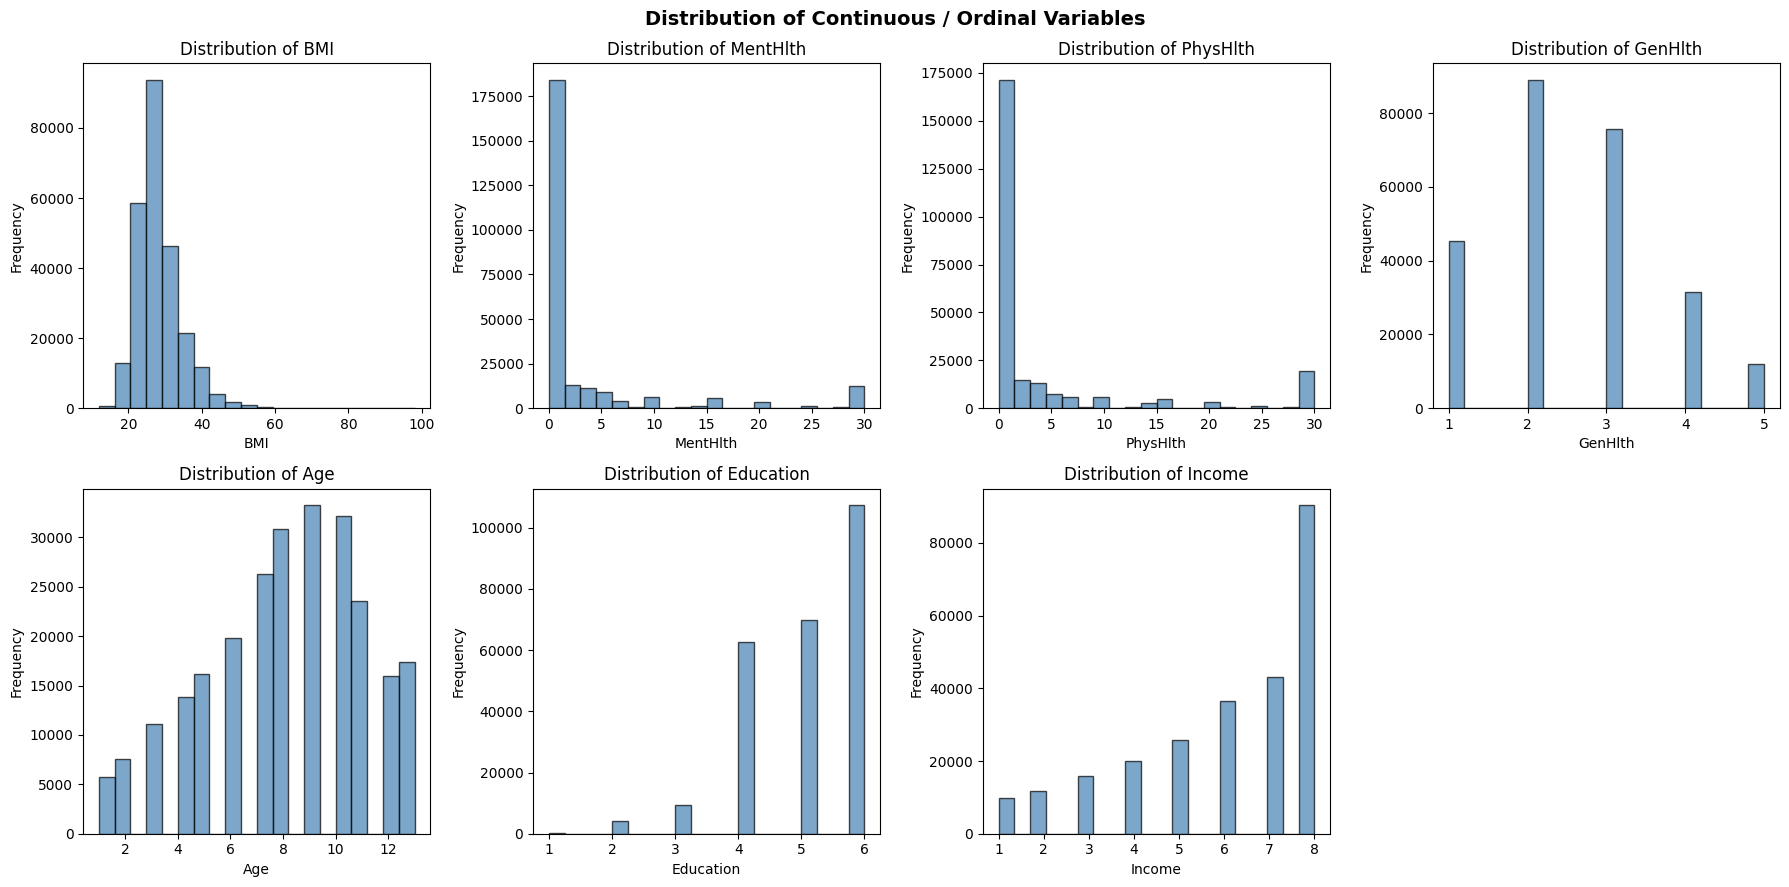

In [69]:
continuous_cols = ['BMI', 'MentHlth', 'PhysHlth', 'GenHlth', 'Age', 'Education', 'Income']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].hist(df_USA_BRFSS[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off')
plt.suptitle('Distribution of Continuous / Ordinal Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

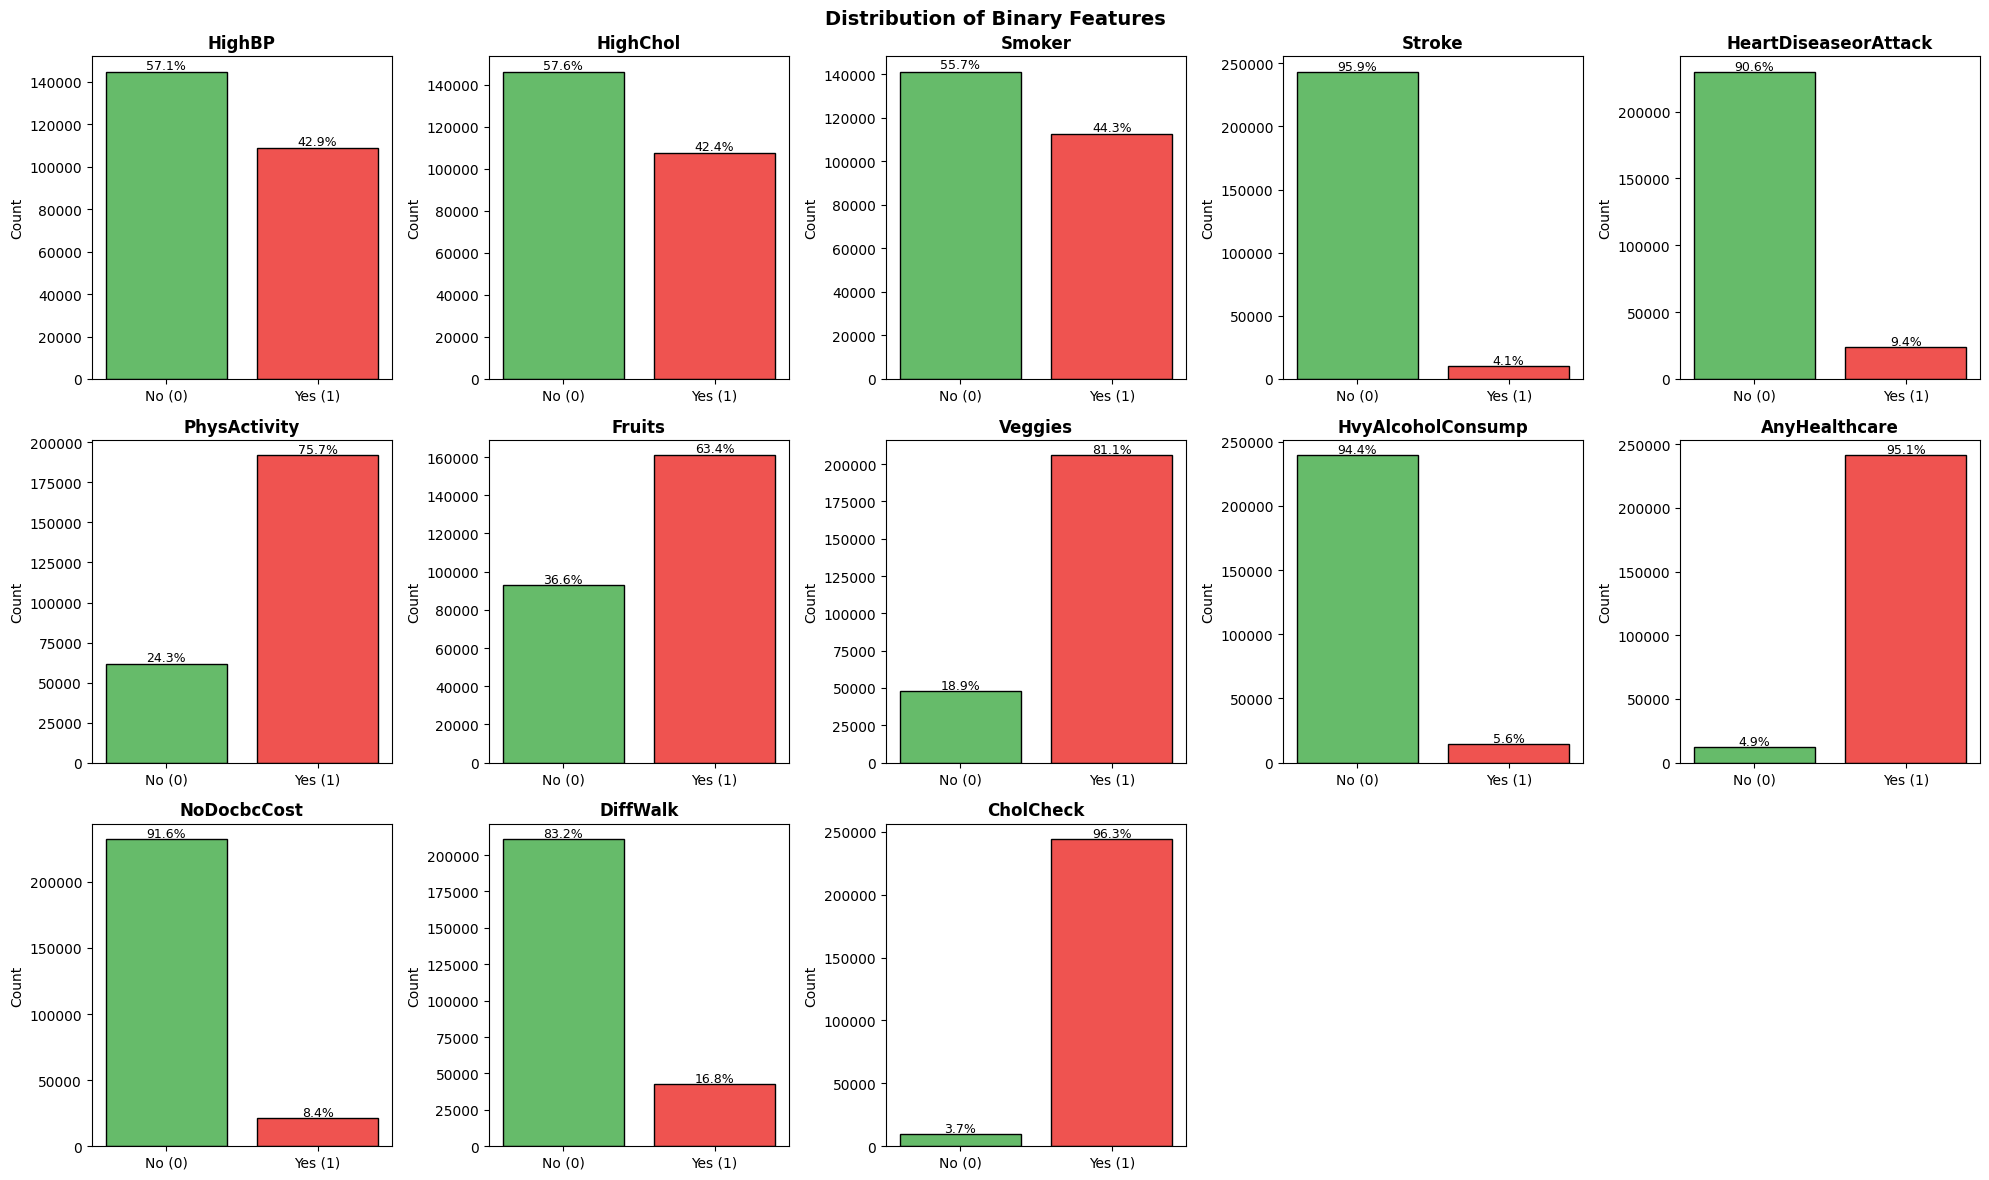

In [73]:
binary_cols = ['HighBP', 'HighChol', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
               'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump',
               'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'CholCheck']

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    counts = df_USA_BRFSS[col].value_counts()
    axes[i].bar(['No (0)', 'Yes (1)'], [counts.get(0, 0), counts.get(1, 0)],
                color=['#66BB6A', '#EF5350'], edgecolor='black')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Count')
    total = len(df_USA_BRFSS)
    for j, val in enumerate([counts.get(0, 0), counts.get(1, 0)]):
        axes[i].text(j, val + 1500, f'{val/total*100:.1f}%', ha='center', fontsize=9)

for j in range(len(binary_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribution of Binary Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# DATA PREPARATION (PROCESS)


## **USA Dataset Preparation**

Firstly, we check for and remove duplicate rows from the dataset. Duplicates can inflate results and bias the model. We found 24,206 duplicate rows (9.54%) which we remove.

In [ ]:
print(f"Rows before removing duplicates: {len(df_USA_BRFSS):,}")
df_USA_BRFSS = df_USA_BRFSS.drop_duplicates()
print(f"Rows after removing duplicates:  {len(df_USA_BRFSS):,}")
print(f"Duplicates removed: {253680 - len(df_USA_BRFSS):,}")

We examine BMI for extreme outliers. We realised that the maximum BMI is 98, which is almost certainly a data entry error. We cap BMI at 60, as values beyond this are medically implausible for most cases. A box plot is used to visualise the distribution before and after capping.

In [ ]:
print(f"BMI range before: {df_USA_BRFSS['BMI'].min()} – {df_USA_BRFSS['BMI'].max()}")
print(f"Rows with BMI > 60: {(df_USA_BRFSS['BMI'] > 60).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_USA_BRFSS['BMI'].plot(kind='box', ax=axes[0])
axes[0].set_title('BMI — Before Cleaning')

df_USA_BRFSS['BMI'] = df_USA_BRFSS['BMI'].clip(upper=60)

df_USA_BRFSS['BMI'].plot(kind='box', ax=axes[1])
axes[1].set_title('BMI — After Capping at 60')

plt.tight_layout()
plt.show()

print(f"BMI range after: {df_USA_BRFSS['BMI'].min()} – {df_USA_BRFSS['BMI'].max()}")

The Age column in this dataset uses BRFSS coded categories (1–13), where each number represents an age range. We convert these to midpoint ages so they are compatible with the India and NHANES datasets, which use actual ages.

In [ ]:
age_map = {
    1: 21, 2: 27, 3: 32, 4: 37, 5: 42, 6: 47, 7: 52,
    8: 57, 9: 62, 10: 67, 11: 72, 12: 77, 13: 82
}

df_USA_BRFSS['Age'] = df_USA_BRFSS['Age'].map(age_map)

print("Age values after conversion:")
print(df_USA_BRFSS['Age'].value_counts().sort_index())

We select only the columns that are common across all three datasets (USA, India, NHANES) and rename them to a standardised format. This ensures consistency when merging later. We also add a source column to track the origin of each row after merging.

In [ ]:
# Select and rename columns to match the agreed merge format
df_AMERICAA_clean = df_USA_BRFSS[[
    'Diabetes_binary', 'BMI', 'Age', 'Sex', 'HighBP',
    'Smoker', 'HighChol', 'PhysActivity'
]].copy()

df_AMERICAA_clean = df_AMERICAA_clean.rename(columns={
    'Diabetes_binary': 'diabetes',
    'BMI': 'bmi',
    'Age': 'age',
    'Sex': 'gender',
    'HighBP': 'hypertension',
    'Smoker': 'smoking',
    'HighChol': 'high_cholesterol',
    'PhysActivity': 'physical_activity'
})

# Add source column
df_AMERICAA_clean['source'] = 'USA'

print("Cleaned dataset columns:")
print(df_AMERICAA_clean.columns.tolist())
print(f"\nShape: {df_AMERICAA_clean.shape}")
df_AMERICAA_clean.head()

We perform a final check on the cleaned dataset to verify there are no missing values, confirm the data types are correct, and review the summary statistics before exporting.

In [ ]:
print(f"Final shape: {df_AMERICAA_clean.shape[0]:,} rows × {df_AMERICAA_clean.shape[1]} columns")
print(f"\nMissing values:")
display(df_AMERICAA_clean.isnull().sum().to_frame("Missing Count"))
print(f"\nData types:")
display(df_AMERICAA_clean.dtypes)
print(f"\nSummary statistics:")
display(df_AMERICAA_clean.describe().round(2))

We export the cleaned USA dataset as a CSV file, ready for merging with the India and NHANES datasets.

In [ ]:
df_AMERICAA_clean.to_csv('/content/drive/MyDrive/SC3021/USA_diabetes_cleaned.csv', index=False)
print("Exported: USA_diabetes_cleaned.csv")
print(f"Rows: {len(df_AMERICAA_clean):,}")
print(f"Columns: {df_AMERICAA_clean.shape[1]}")